
# Movie Data Analysis using Pandas, NumPy, Seaborn & Matplotlib


###  Libraries Used:
- **pandas** → Data cleaning and transformation  
- **numpy** → Statistical analysis  
- **seaborn** & **matplotlib** → Data visualization

###  Objectives:
1. Clean and explore the dataset  
2. Derive insights about movie trends, ratings, and revenues  
3. Visualize patterns using charts and graphs


In [28]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
movies = pd.read_csv(r"C:\Users\sabar\OneDrive\Desktop\Data\movies.csv")
movies.head()


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


##  Data Cleaning

In [29]:

# Check for missing values
print("Missing values per column:")
print(movies.isnull().sum())

# Drop duplicates
movies.drop_duplicates(inplace=True)

# Fill missing numerical values with median
num_cols = movies.select_dtypes(include=[np.number]).columns
movies[num_cols] = movies[num_cols].fillna(movies[num_cols].median())

# Fill missing categorical values with mode
cat_cols = movies.select_dtypes(include=['object']).columns
for col in cat_cols:
    movies[col] = movies[col].fillna(movies[col].mode()[0])

print("\nCleaned dataset shape:", movies.shape)
movies.info()


Missing values per column:
name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

Cleaned dataset shape: (7668, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7668 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7668 non-null   object 
 5   score     7668 non-null   float64
 6   votes     7668 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7668 non-null   object 
 9   star      7668 non-null   object 
 10  country   7668 non-null   object 
 11  budget    7668 non-null   float64
 12  gross     76

##  Exploratory Data Analysis (EDA)

              score         gross
genre                            
Animation  6.769231  2.372860e+08
Family     6.363636  1.961725e+08
Action     6.202991  1.431569e+08
Adventure  6.291569  1.078643e+08
Mystery    6.665000  1.011835e+08


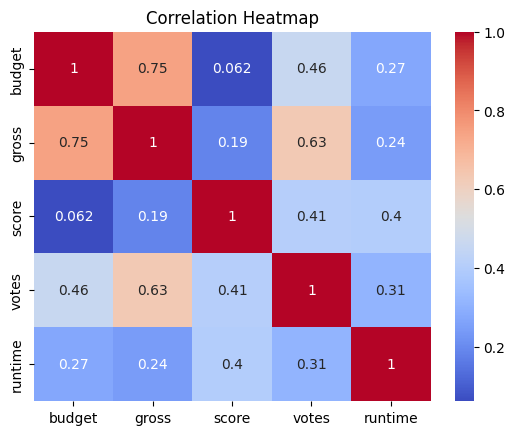

In [30]:

# Average movie score and gross by genre
genre_summary = movies.groupby('genre')[['score', 'gross']].mean().sort_values('gross', ascending=False)
print(genre_summary.head())

# Correlation matrix
corr = movies[['budget', 'gross', 'score', 'votes', 'runtime']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


##  Statistical Summary using NumPy

In [31]:

numeric_data = movies[['budget', 'gross', 'score', 'votes', 'runtime']]
print("Mean values:\n", np.mean(numeric_data, axis=0))
print("\nMedian values:\n", np.median(numeric_data, axis=0))
print("\nStandard deviation:\n", np.std(numeric_data, axis=0))


Mean values:
 budget     3.131756e+07
gross      7.706370e+07
score      6.390454e+00
votes      8.808694e+04
runtime    1.072599e+02
dtype: float64

Median values:
 [2.0500000e+07 2.0205757e+07 6.5000000e+00 3.3000000e+04 1.0400000e+02]

Standard deviation:
 budget     3.575040e+07
gross      1.639085e+08
score      9.685913e-01
votes      1.632848e+05
runtime    1.857534e+01
dtype: float64


##  Data Visualizations

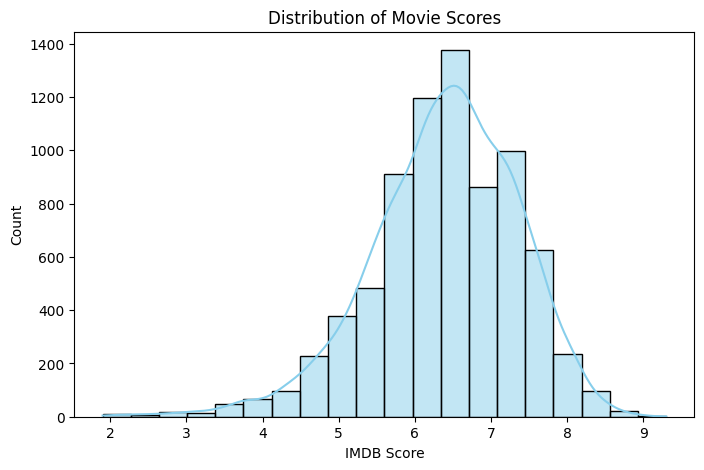

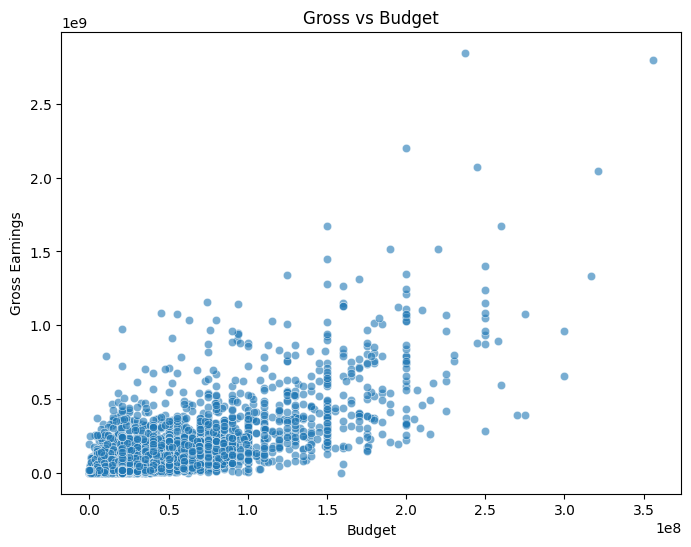

C:\Users\sabar\AppData\Local\Temp\ipykernel_25416\1450509253.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette='viridis')


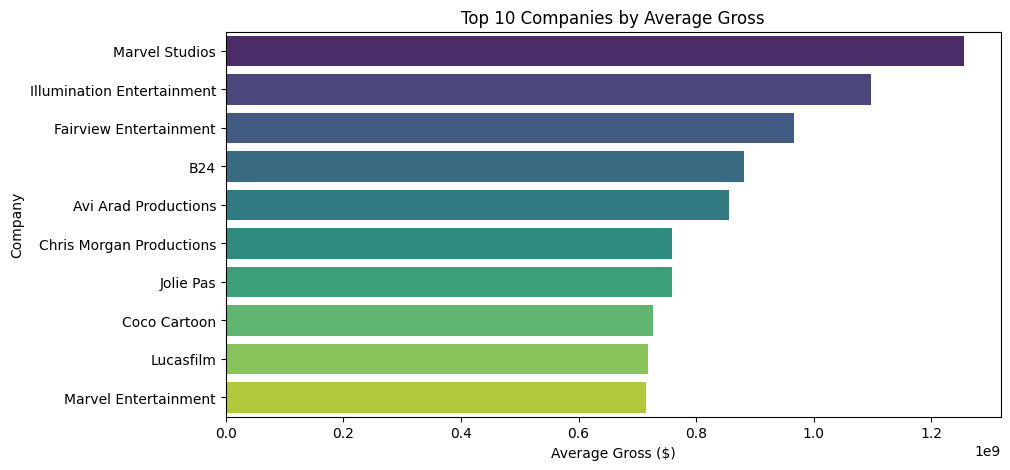

In [32]:

# Distribution of movie scores
plt.figure(figsize=(8,5))
sns.histplot(movies['score'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Movie Scores')
plt.xlabel('IMDB Score')
plt.ylabel('Count')
plt.show()

# Gross vs Budget
plt.figure(figsize=(8,6))
sns.scatterplot(x='budget', y='gross', data=movies, alpha=0.6)
plt.title('Gross vs Budget')
plt.xlabel('Budget')
plt.ylabel('Gross Earnings')
plt.show()

# Top 10 companies by average gross
top_companies = movies.groupby('company')['gross'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_companies.values, y=top_companies.index, palette='viridis')
plt.title('Top 10 Companies by Average Gross')
plt.xlabel('Average Gross ($)')
plt.ylabel('Company')
plt.show()



##  Conclusion

- The dataset was cleaned and analyzed using **Pandas** and **NumPy**.  
- **Seaborn** and **Matplotlib** helped visualize relationships between key metrics.  
- Insights such as top genres, company performance, and budget‑gross correlations were explored.  

